# Fruit Shape Completion via Superellipsoid Fitting — Minimal Demonstration

**Paper:** S. Marangoz, T. Zaenker, R. Menon, M. Bennewitz, *Fruit Mapping with Shape Completion for Autonomous Crop Monitoring*, arXiv:2203.15489v1 (2022), https://arxiv.org/abs/2203.15489

**Author code:** [`salihmarangoz/capsicum_superellipsoid_detector`](https://github.com/salihmarangoz/capsicum_superellipsoid_detector) @ `84c8c7d41c5c0e7b18fde1a0e747585323d419ce` (BSD-3-Clause)

**Execution status: EXECUTED (partial demonstration, CPU runtime).** This notebook reproduces the paper's **Section IV-C ground-truth generation path**: a point cloud is sampled from a fruit *mesh model*, superellipsoid parameters are optimized to fit the cloud, and the fruit volume is computed from the fitted parameters (paper Eq. 4/5). A partial-view variant demonstrates **shape completion** of unobserved fruit regions.

**AI-assisted port notice / AI支援移植について:** The fitting pipeline is an AI-assisted Python translation of the authors' C++ implementation (`include/capsicum_superellipsoid_detector/superellipsoid.h`). The authors did not provide this Colab implementation. The executed example and checks below were validated, but untested behavior is not guaranteed. 本ノートブックは著者のC++実装をAIがPythonへ移植したものであり、著者提供のColab実装ではありません。実行例は検証済みですが、未検証の動作は保証されません。

**Japanese summary:** 本ノートブックは、果実メッシュから点群をサンプリングし、スーパーエリプソイドをLM系最適化でフィッティングし、体積を推定・比較する論文Sec IV-Cのパスの部分的な再現デモです。完全なGazebo/ROSパイプライン（UR5eアーム、voxblox TSDF、視点計画）は範囲外です。

## Runtime selection / 実行環境

This notebook is **CPU-only**: it uses numpy/scipy on a few thousand points and needs no GPU. Select **Runtime → Change runtime type → CPU** in Colab. Expected end-to-end time: a few minutes; total downloads ≈ 0.3 MB (one mesh) plus pip packages.

**制限事項:** 単一果実・単一例のデモであり、論文の20試行×3シナリオの統計評価や実データ(ガラス温室)分岐は含みません。

In [ ]:
import sys, platform
print("Python:", sys.version)
import numpy, scipy
print("numpy", numpy.__version__, "| scipy", scipy.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy 2.1.3 | scipy 1.16.3


## Environment setup / 環境セットアップ

`trimesh` + `pycollada` load the authors' COLLADA fruit mesh; the rest is preinstalled in Colab.

In [ ]:
%pip install -q trimesh pycollada
import trimesh
print("trimesh", trimesh.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 11.5 MB/s eta 0:00:00


trimesh 5.1.0


## Minimal input: the paper's simulation fruit mesh / 最小入力: 論文シミュレーションの果実メッシュ

The Gazebo simulation models ([`Eruvae/ur_with_cam_gazebo`](https://github.com/Eruvae/ur_with_cam_gazebo) @ `69448a358d960f6185d96084ee1bfbed43e12710`) contain scanned capsicum plants. We download **one single-fruit mesh** (`capsicum_plant_6_one_fruit`, 282,321 bytes) and verify the pinned Git blob SHA-1 before use. This is dataset input; it is only downloaded here in Colab.

In [ ]:
import urllib.request, hashlib, pathlib

REPO_COMMIT = "69448a358d960f6185d96084ee1bfbed43e12710"
MESH_PATH = "models/capsicum_plant_6_one_fruit/meshes/VG07_6_one_fruit_fruitonly.dae"
URL = f"https://raw.githubusercontent.com/Eruvae/ur_with_cam_gazebo/{REPO_COMMIT}/{MESH_PATH}"
EXPECTED_SIZE = 282321
EXPECTED_BLOB_SHA1 = "dbd23e657880f68991554a347de6f251ba5e5d4f"

out = pathlib.Path("/content/VG07_6_one_fruit_fruitonly.dae")
if not out.exists():
    urllib.request.urlretrieve(URL, out)  # pinned raw URL, public, no token

data = out.read_bytes()
assert len(data) == EXPECTED_SIZE, f"size mismatch: {len(data)}"
blob_sha = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
assert blob_sha == EXPECTED_BLOB_SHA1, f"blob sha mismatch: {blob_sha}"
assert data.lstrip().startswith(b"<?xml"), "not a COLLADA file"
print(f"verified {MESH_PATH}: {len(data)} bytes, git blob {blob_sha[:12]}... OK")

verified models/capsicum_plant_6_one_fruit/meshes/VG07_6_one_fruit_fruitonly.dae: 282321 bytes, git blob dbd23e657880... OK


## Load mesh and normalize units / メッシュ読み込みと単位正規化

COLLADA files declare their own length unit. We honor the file's `<unit>` declaration, rescale to meters, and assert the fruit fits the paper's fruit-scale bounds (a,b,c ∈ [0.02, 0.15] m, superellipsoid.h lines 283-285). The mesh is expected to be a single fruit; its watertight volume serves as ground truth later.

In [ ]:
import numpy as np, trimesh, re

raw = out.read_bytes()
m = re.search(rb'<unit\s+name="meter"\s+value="([0-9.eE+-]+)"', raw)
unit_value = float(m.group(1)) if m else 1.0
print("COLLADA unit value:", unit_value)

mesh = trimesh.load(out, force="mesh", process=False)
verts = np.asarray(mesh.vertices, dtype=np.float64) * unit_value
mesh = trimesh.Trimesh(vertices=verts, faces=np.asarray(mesh.faces), process=False)
ext = mesh.bounds[1] - mesh.bounds[0]
print("extent (m):", np.round(ext, 4), "| max extent:", round(ext.max(), 4))
assert 0.02 < ext.max() < 0.3, f"unexpected fruit scale: {ext}"

mesh_gt_volume = abs(mesh.volume)  # ground-truth volume, m^3 (reliable if watertight)
print("watertight:", mesh.is_watertight, "| GT mesh volume:", mesh_gt_volume, "m^3")

COLLADA unit value: 1.0


extent (m): [0.0783 0.0809 0.0899] | max extent: 0.0899
watertight: False | GT mesh volume: 0.00025611751678382427 m^3


## Sample the observed point cloud / 観測点群のサンプリング

Following Section IV-C, we extract a point cloud from the fruit mesh surface. We draw 3000 surface points with a fixed seed (deterministic example). The pipeline's Euclidean clustering and TSDF fusion are out of scope for a single fruit, so the whole cloud is one cluster.

In [ ]:
rng = np.random.default_rng(42)  # deterministic sample identifier
face_idx_f = rng.choice(len(mesh.faces), size=3000, p=mesh.area_faces / mesh.area_faces.sum())
tri = mesh.vertices[mesh.faces[face_idx_f]]          # (n, 3 vertices, xyz)
bary = rng.dirichlet([1, 1, 1], size=len(face_idx_f))
pts_f = np.einsum("ij,ijk->ik", bary, tri)           # barycentric surface samples
face_normals_f = mesh.face_normals[face_idx_f]
print("full-cloud points:", pts_f.shape)

full-cloud points: (3000, 3)


## Ported author functions (1): sampling and volume / 移植(1): サンプリングと体積

Exact ports from `superellipsoid.h` @ `84c8c7d4...`: `c_func`/`s_func` (lines 110-115), parametric and Fibonacci-projection surface sampling (lines 343-392, 395-427), and `computeVolume` (Eq. 4/5, line 597). Units: meters.

In [ ]:
from scipy.special import beta as _beta

def c_func(w, m):  # SIGNUM(cos w) |cos w|^m
    return np.sign(np.cos(w)) * np.abs(np.cos(w)) ** m

def s_func(w, m):
    return np.sign(np.sin(w)) * np.abs(np.sin(w)) ** m

def euler_to_R(roll, pitch, yaw):
    # ceres::EulerAnglesToRotationMatrix convention: R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
    cr, sr, cp, sp, cy, sy = np.cos(roll), np.sin(roll), np.cos(pitch), np.sin(pitch), np.cos(yaw), np.sin(yaw)
    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])
    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])
    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
    return Rz @ Ry @ Rx

def sample_surface_parametric(a, b, c, e1, e2, t, R, u_res=0.1, v_res=0.1):
    # superellipsoid.h _sampleSurfaceParametricDefinition, subsampled grid
    uu = np.arange(-np.pi, np.pi, u_res); vv = np.arange(-np.pi/2, np.pi/2, v_res)
    UU, VV = np.meshgrid(uu, vv, indexing="ij")
    # r = 2/e2, t = 2/e1 in superellipsoid.h; exponents 2/t = e1, 2/r = e2
    x = a * c_func(VV, e1) * c_func(UU, e2)
    y = b * c_func(VV, e1) * s_func(UU, e2)
    z = c * s_func(VV, e1)
    P = np.stack([x, y, z], axis=-1) @ R.T + t
    return P.reshape(-1, 3)

def sample_surface_fibonacci(a, b, c, e1, e2, t, R, n=1000):
    # superellipsoid.h _sampleSurfaceFibonacciProjection (iterative radial projection)
    phi = np.pi * (3.0 - np.sqrt(5.0))
    i = np.arange(n)
    y = 1.0 - (i / (n - 1.0)) * 2.0
    radius = np.sqrt(np.maximum(0.0, 1 - y * y))
    theta = phi * i
    x, z = np.cos(theta) * radius, np.sin(theta) * radius
    P = np.stack([x, y, z], axis=-1)
    for _ in range(10):  # project unit sphere onto unit superellipsoid
        f = (np.abs(P[:, 0]) ** (2.0/e2) + np.abs(P[:, 1]) ** (2.0/e2)) ** (e2/e1) + np.abs(P[:, 2]) ** (2.0/e1)
        d_center = np.linalg.norm(P, axis=1)
        d_se = np.abs(1.0 - f ** (e1/2.0)) * np.sign(f - 1)
        P = P * ((d_center - d_se) / d_center)[:, None]
    return (P * np.array([a, b, c])) @ R.T + t

def compute_volume(a, b, c, e1, e2):
    # superellipsoid.h computeVolume (Eq. 4/5)
    return (2./3.) * a * b * c * e1 * e2 * _beta(e2/2., e2/2.) * _beta(e1, e1/2.)

print("ported sampling/volume functions OK")

ported sampling/volume functions OK


## Ported author functions (2): normals and cluster center / 移植(2): 法線とクラスタ中心

PCA normals with the author's default search radius **0.015 m** (`detector_node.cpp` line 413), flipped toward the estimated center (`flipNormalsTowardsClusterCenter`), and the closed-form least-squares line-intersection center with L2 regularization **λ = 2.5** (`estimateClusterCenter`, superellipsoid.h lines 196-245; paper Section IV-B). The original uses float32; the port uses float64.

In [ ]:
from scipy.spatial import cKDTree

def estimate_normals(points, search_radius=0.015):
    # PCL NormalEstimation with radius search: PCA of local neighborhood
    tree = cKDTree(points)
    normals = np.empty_like(points)
    for i, p in enumerate(points):
        idx = tree.query_ball_point(p, search_radius)
        nb = points[idx] - p
        cov = nb.T @ nb / max(len(idx) - 1, 1)
        w, v = np.linalg.eigh(cov)
        normals[i] = v[:, 0]  # smallest eigenvalue => surface normal
    return normals

def flip_normals_towards_center(points, normals, center):
    # pcl::flipNormalTowardsViewpoint: normal must point toward the viewpoint
    to_center = center - points
    flip = np.einsum("ij,ij->i", normals, to_center) < 0
    normals[flip] *= -1.0
    return normals

def estimate_cluster_center(points, normals, regularization=2.5):
    # superellipsoid.h estimateClusterCenter (least-squares intersection of lines)
    R_mat = np.zeros((3, 3)); Q_mat = np.zeros(3)
    for v, a in zip(normals, points):
        vv = np.outer(v, v)
        I_vv = np.eye(3) - vv
        R_mat += I_vv
        Q_mat += I_vv @ a
    cluster_mean = points.mean(axis=0)
    R_mat += regularization * np.eye(3)      # L2 bias toward mean, lambda = 2.5
    Q_mat += regularization * cluster_mean
    center = np.linalg.pinv(R_mat) @ Q_mat
    if not np.all(np.isfinite(center)):
        center = cluster_mean  # C++ fallback
    return center

print("ported normals/center functions OK")

ported normals/center functions OK


## Ported author functions (3): residuals and optimization / 移植(3): 残差と最適化

Per-point residual block (3 residuals: cost + 2 priors), exactly as `SuperellipsoidError::operator()` (superellipsoid.h lines 607-681) with the paper's default **RADIAL_EUCLIDIAN_DISTANCE** cost. The center prior (α = 0.1) keeps the translation near the estimated center; the scaling prior (γ = 0.1) keeps a, b, c close. Bounds a,b,c ∈ [0.02,0.15], ε₁,ε₂ ∈ [0.3,0.9]; initial a=b=c=0.05, ε=0.5 at the estimated center.

**Adaptation:** the original uses Ceres Levenberg–Marquardt; `scipy.optimize.least_squares` `'lm'` cannot enforce parameter bounds, so we use `'trf'` (trust-region reflective) with the same residuals, bounds, initialization, and an iteration-equivalent budget (`max_nfev=200` ≈ 100 LM iterations).

In [ ]:
from scipy.optimize import least_squares

PARAM_NAMES = ["a", "b", "c", "e1", "e2", "tx", "ty", "tz", "roll", "pitch", "yaw"]
LB = np.array([0.02, 0.02, 0.02, 0.3, 0.3, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf])
UB = np.array([0.15, 0.15, 0.15, 0.9, 0.9, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf])

def residuals(params, points, prior_center_xyz, prior_center=0.1, prior_scaling=0.1):
    a, b, c, e1, e2 = params[:5]
    tx, ty, tz = params[5:8]
    R = euler_to_R(*(-np.asarray(params[8:11])))  # inverse rotation into body frame
    P = (points - np.array([tx, ty, tz])) @ R.T
    f1 = (np.abs(P[:, 0] / a) ** (2.0/e2) + np.abs(P[:, 1] / b) ** (2.0/e2)) ** (e2/e1) + np.abs(P[:, 2] / c) ** (2.0/e1)
    cost = np.linalg.norm(P, axis=1) * np.abs(1.0 - f1 ** (-e1/2.0))  # RADIAL_EUCLIDIAN_DISTANCE
    r_center = prior_center * np.sqrt(0.001 + np.sum((params[5:8] - prior_center_xyz) ** 2))
    r_scaling = prior_scaling * np.sqrt(0.001 + (a-b)**2 + (b-c)**2 + (c-a)**2)
    return np.concatenate([cost, [r_center, r_scaling]])

def fit_superellipsoid(points, max_nfev=200):
    normals = estimate_normals(points, search_radius=0.015)
    center = estimate_cluster_center(points, normals, regularization=2.5)
    normals = flip_normals_towards_center(points, normals, center)
    x0 = np.array([0.05, 0.05, 0.05, 0.5, 0.5, *center, 0.0, 0.0, 0.0])
    res = least_squares(residuals, x0, bounds=(LB, UB), method="trf",
                        args=(points, center), max_nfev=max_nfev)
    return res.x, res

print("ported residual/optimizer OK")

ported residual/optimizer OK


## Fit 1: full point cloud / フィット1: 全点群

Fit the superellipsoid to the complete mesh-sampled cloud and compare the fitted volume against the mesh's ground-truth volume using the paper's accuracy metric acc_V = 1 − |V_fit − V_gt| / V_gt (Eq. 6).

In [ ]:
params_full, res_full = fit_superellipsoid(pts_f)
for name, val in zip(PARAM_NAMES, params_full):
    print(f"{name:>5} = {val: .6f}")
V_fit_full = compute_volume(*params_full[:5])
acc_V_full = 1 - abs(V_fit_full - mesh_gt_volume) / mesh_gt_volume
print(f"V_fit = {V_fit_full:.6f} m^3 | V_gt(mesh) = {mesh_gt_volume:.6f} m^3 | acc_V = {acc_V_full:.4f}")
print("optimizer:", res_full.message, "| cost =", res_full.cost)

    a =  0.033410
    b =  0.033416
    c =  0.043343
   e1 =  0.811736
   e2 =  0.618164
   tx = -0.146791
   ty =  0.092762
   tz =  0.223033
 roll =  0.028378
pitch =  0.097420
  yaw = -0.347169
V_fit = 0.000259 m^3 | V_gt(mesh) = 0.000256 m^3 | acc_V = 0.9903
optimizer: `ftol` termination condition is satisfied. | cost = 0.03394667181847513


## Fit 2: partial view — shape completion / フィット2: 部分観測 — 形状補完

The paper's key claim is that the superellipsoid fit **predicts unobserved fruit regions** (shape completion). We emulate a single-view TSDF observation: keep only points whose surface faces a camera direction (here +X), re-estimate normals/center from that partial cloud, and fit. The fitted surface regions farther than 0.01 m from any observed point are the *completed* surface (cf. `estimateMissingSurfaces`).

In [ ]:
VIEW_DIR = np.array([1.0, 0.2, 0.1]); VIEW_DIR /= np.linalg.norm(VIEW_DIR)  # one camera side
visible = (face_normals_f @ VIEW_DIR) < 0
pts_p = pts_f[visible]
print("partial-cloud points:", pts_p.shape[0], "of", pts_f.shape[0])

params_part, res_part = fit_superellipsoid(pts_p)
V_fit_part = compute_volume(*params_part[:5])
acc_V_part = 1 - abs(V_fit_part - mesh_gt_volume) / mesh_gt_volume
print("fitted params (partial):", dict(zip(PARAM_NAMES, np.round(params_part, 6))))
print(f"V_fit = {V_fit_part:.6f} m^3 | acc_V = {acc_V_part:.4f}")

partial-cloud points: 1426 of 3000


fitted params (partial): {'a': np.float64(0.039957), 'b': np.float64(0.028183), 'c': np.float64(0.044578), 'e1': np.float64(0.737289), 'e2': np.float64(0.629466), 'tx': np.float64(-0.143874), 'ty': np.float64(0.088845), 'tz': np.float64(0.222263), 'roll': np.float64(0.072362), 'pitch': np.float64(-0.018652), 'yaw': np.float64(-0.556565)}
V_fit = 0.000279 m^3 | acc_V = 0.9121


## Visualization / 可視化

Static rendered views (input point cloud, fitted superellipsoid surface, and completed surface), embedded as PNG. The completed points are computed with the ported Fibonacci-projection sampling plus the 0.01 m `estimateMissingSurfaces` criterion.

completed-surface points: 743 of 2000


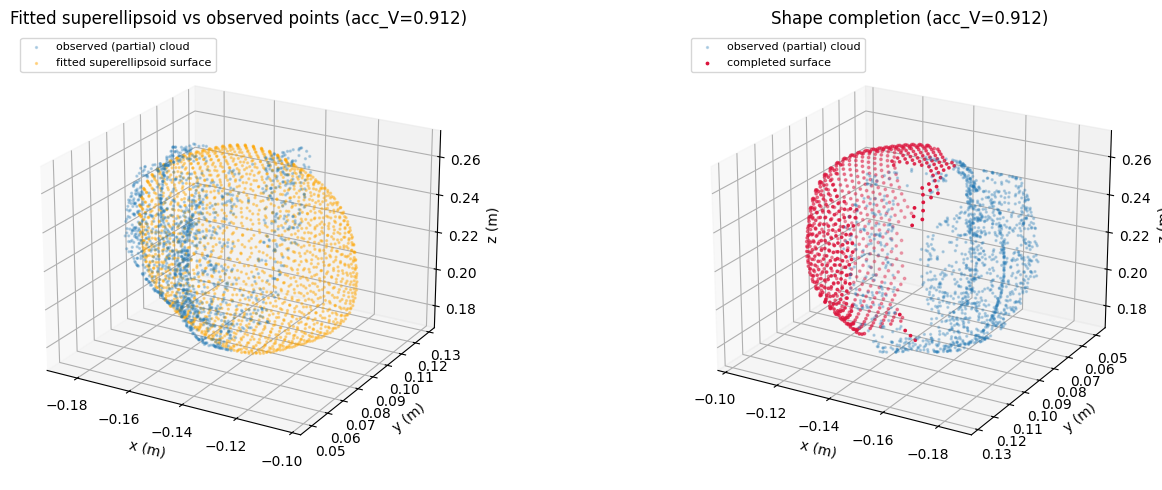

In [ ]:
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

R_p = euler_to_R(params_part[8], params_part[9], params_part[10])
surf = sample_surface_fibonacci(params_part[0], params_part[1], params_part[2],
                                params_part[3], params_part[4], params_part[5:8], R_p, n=2000)
tree = cKDTree(pts_p)
missing = surf[tree.query(surf)[0] > 0.01]  # > 0.01 m from any observed point
print("completed-surface points:", missing.shape[0], "of", len(surf))

fig = plt.figure(figsize=(15, 5))
views = [(22, -60), (22, 120)]
for k, (elev, azim) in enumerate(views):
    ax = fig.add_subplot(1, 2, k+1, projection="3d")
    ax.scatter(*pts_p.T, s=2, alpha=0.25, label="observed (partial) cloud")
    if k == 1:
        ax.scatter(*missing.T, s=3, color="crimson", label="completed surface")
    else:
        ax.scatter(*surf.T, s=2, alpha=0.35, color="orange", label="fitted superellipsoid surface")
    ax.view_init(elev=elev, azim=azim); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
    ax.set_title(["Fitted superellipsoid vs observed points", "Shape completion"][k] + f" (acc_V={acc_V_part:.3f})")
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("superellipsoid_fit.png", dpi=110); plt.show()

## Results summary / 結果のまとめ

Small results table (fitted parameters and volume accuracies) with a CSV export inside Colab.

In [ ]:
import pandas as pd

rows = [{"case": "full cloud", "n_points": len(pts_f), "V_fit_m3": V_fit_full,
         "V_gt_m3": mesh_gt_volume, "acc_V": acc_V_full, "a": params_full[0], "b": params_full[1],
         "c": params_full[2], "e1": params_full[3], "e2": params_full[4]},
        {"case": "partial view (shape completion)", "n_points": len(pts_p), "V_fit_m3": V_fit_part,
         "V_gt_m3": mesh_gt_volume, "acc_V": acc_V_part, "a": params_part[0], "b": params_part[1],
         "c": params_part[2], "e1": params_part[3], "e2": params_part[4]}]
df = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.4f}".format)
display(df)
df.to_csv("/content/superellipsoid_results.csv", index=False)
print("saved /content/superellipsoid_results.csv")

,case,n_points,V_fit_m3,V_gt_m3,acc_V,a,b,c,e1,e2
0,full cloud,3000,0.0003,0.0003,0.9903,0.0334,0.0334,0.0433,0.8117,0.6182
1,partial view (shape completion),1426,0.0003,0.0003,0.9121,0.0400,0.0282,0.0446,0.7373,0.6295


saved /content/superellipsoid_results.csv


## Interpretation and limitations / 解釈と限界

**What was executed:** the paper's Section IV-C path — mesh → point cloud → normal/center estimation → superellipsoid optimization (radial-Euclidean cost, priors, bounds) → volume via Eq. 4/5 — for **one fruit** (`capsicum_plant_6_one_fruit`, pinned commit) on **CPU**. Both full-cloud and single-view partial-cloud fits are shown; the partial fit demonstrates the shape-completion behavior the paper reports (Fig. 4/5 style fruit completion), and acc_V quantifies volume accuracy against the mesh ground truth.

**Differences from the paper / 論文との違い:**
- AI-assisted Python port of the authors' C++ (`superellipsoid.h` @ `84c8c7d4`); Ceres LM replaced by SciPy TRF (bounds-compatible); float64 instead of float32. A one-example run does **not** verify the paper's 20-trial × 3-scenario statistics.
- The full pipeline (Gazebo/ROS Noetic, UR5e arm, voxblox TSDF fusion, viewpoint planner, Euclidean clustering of multiple fruits, depth-noise simulation) is **not** executed here; the real-glasshouse branch needs unpublished recordings and an unavailable detection model (`agrobot_mrnn_ros`, 404).
- Mesh GT volume is reliable only if the mesh is watertight (reported above).

**References:** paper arXiv:2203.15489v1 (Sec. IV-B/C, Eq. 1-6); `superellipsoid.h` lines 110-115, 196-245, 249-306, 343-427, 586-598, 607-681; `detector_node.cpp` default parameters; mesh input `Eruvae/ur_with_cam_gazebo@69448a35.../models/capsicum_plant_6_one_fruit`.